In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [4]:
# Read Dataset
df = pd.read_csv("thyroid.csv", sep=";")
df.head(3)

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,lithium,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label,Unnamed: 22,Unnamed: 23
0,0.45,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,61.0,6.0,23.0,87.0,26.0,o,NaN,NaN
1,0.61,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,29.0,15.0,61.0,96.0,64.0,o,NaN,NaN
2,0.16,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,29.0,19.0,58.0,103.0,56.0,o,NaN,NaN


In [11]:
# Transformation
X = df.drop(columns=["Outlier_label ", 'Unnamed: 22', 'Unnamed: 23'])
y = df["Outlier_label "]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
# Isolation Forest
from sklearn.ensemble import IsolationForest

clf = IsolationForest(
    n_estimators=200,
    contamination='auto',
    random_state=42
)
labels = clf.fit_predict(X_scaled)

Text(0, 0.5, 'PC2')

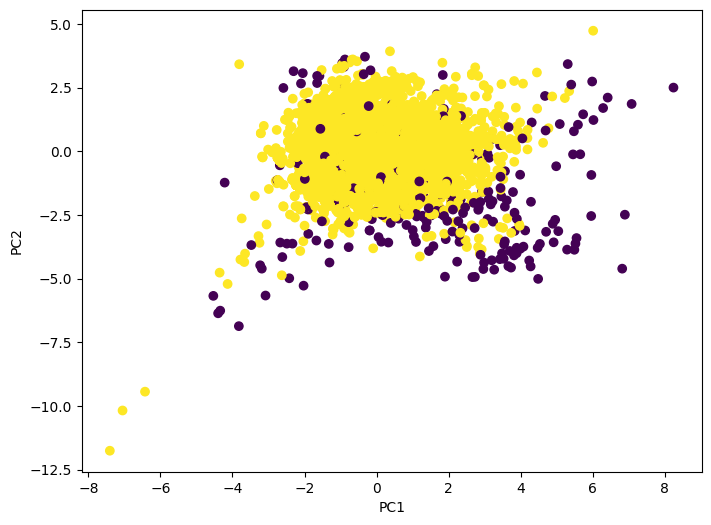

In [13]:
# Visualize
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
plt.xlabel("PC1")
plt.ylabel("PC2")

In [14]:
# Count of outliers
import numpy as np

n_outliers = np.sum(labels == -1)
n_normal = np.sum(labels == 1)

print("Outliers: ", n_outliers)
print("Normal: ", n_normal)

Outliers:  270
Normal:  6646
